In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout,Dense
from tensorflow.keras.models  import Sequential
import os
import sklearn as sk
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

In [2]:
data=pd.read_csv("HPLC data.csv")
data.head()

,Sl No,Age,Gender,Religion,Present District,HbA0,HbA2,HbF,S-Window,Unknown,RBC,HB,MCV,MCH,MCHC,RDWcv,Weekness,Jaundice,Diagnosis
0,1,14 Yrs 11 month,Female,Hinduism,Howrah,86.2,2.9,0.3,0.0,0.0,4.81,13.2,86.7,28.8,33.0,13.8,No,No,Normal
1,2,16 Yrs 0 month,Female,Hinduism,Kolkata,86.4,4.8,0.4,0.0,0.0,4.18,10.9,78.9,26.1,33.0,14.6,No,No,Beta Thalassaemia carrier
2,3,16 Yrs 2 month,Male,Hinduism,Hooghly,87.3,3.2,0.5,0.0,0.0,5.31,13.6,87.0,25.6,29.4,13.7,No,No,Normal
3,4,21 Yrs 0 month,Female,Hinduism,South 24-Parganas,87.9,2.8,0.2,0.0,0.0,4.64,11.5,78.7,44.8,31.5,14.5,No,No,Normal
4,5,35 Yrs 3 month,Male,Hinduism,Midnapore (East),84.3,2.8,0.2,0.0,0.0,5.50,14.0,69.7,21.5,30.9,16.5,No,No,Normal


In [3]:
data=data.drop(columns=["Unknown","Sl No","Religion","Present District"])
data.head()

,Age,Gender,HbA0,HbA2,HbF,S-Window,RBC,HB,MCV,MCH,MCHC,RDWcv,Weekness,Jaundice,Diagnosis
0,14 Yrs 11 month,Female,86.2,2.9,0.3,0.0,4.81,13.2,86.7,28.8,33.0,13.8,No,No,Normal
1,16 Yrs 0 month,Female,86.4,4.8,0.4,0.0,4.18,10.9,78.9,26.1,33.0,14.6,No,No,Beta Thalassaemia carrier
2,16 Yrs 2 month,Male,87.3,3.2,0.5,0.0,5.31,13.6,87.0,25.6,29.4,13.7,No,No,Normal
3,21 Yrs 0 month,Female,87.9,2.8,0.2,0.0,4.64,11.5,78.7,44.8,31.5,14.5,No,No,Normal
4,35 Yrs 3 month,Male,84.3,2.8,0.2,0.0,5.50,14.0,69.7,21.5,30.9,16.5,No,No,Normal


In [4]:
print(data.isnull().sum())

Age           6
Gender        0
HbA0          0
HbA2          0
HbF           0
S-Window      0
RBC           0
HB            0
MCV           0
MCH           0
MCHC          0
RDWcv         0
Weekness     10
Jaundice     11
Diagnosis     0
dtype: int64


In [5]:
data=data.dropna()

In [6]:
data.isnull().sum()

Age          0
Gender       0
HbA0         0
HbA2         0
HbF          0
S-Window     0
RBC          0
HB           0
MCV          0
MCH          0
MCHC         0
RDWcv        0
Weekness     0
Jaundice     0
Diagnosis    0
dtype: int64

In [7]:
lb=LabelEncoder()
data["Diagnosis"]=data["Diagnosis"].str.strip()
data["Diagnosis"]=lb.fit_transform(data["Diagnosis"])

lb2=LabelEncoder()
data["Age"]=data["Age"].str.strip()
data["Age"]=lb2.fit_transform(data["Age"])


lb3=LabelEncoder()
data["Weekness"]=data["Weekness"].str.strip()
data["Weekness"]=lb3.fit_transform(data["Weekness"])

lb4=LabelEncoder()
data["Jaundice"]=data["Jaundice"].str.strip()
data["Jaundice"]=lb4.fit_transform(data["Jaundice"])


lb5=LabelEncoder()
data["Gender"]=data["Gender"].str.strip()
data["Gender"]=lb5.fit_transform(data["Gender"])

print(lb.classes_)

['Beta Thalassaemia carrier' 'Beta Thalassaemia major'
 'Beta trait with high foetal haemoglobin' 'Delta beta carrier'
 'HPFH trait' 'HbD carrier' 'HbD disease' 'HbE carrier' 'HbE disease'
 'HbE-Beta Thalassaemia' 'HbS carrier' 'HbS-Beta Thalassaemia' 'Normal']


In [8]:
print(data["Age"])

0         63
1         84
2         88
3        154
4        334
        ... 
13026      2
13027      3
13028      4
13029      4
13030    322
Name: Age, Length: 13013, dtype: int32


In [9]:
print(data["Weekness"].unique())

[0 1]


In [10]:
print(data["Jaundice"].unique())

[0 1]


In [11]:
print(data["Gender"].unique())

[0 1]


In [12]:
print(data["Diagnosis"].unique())

[12  0  7  9 10  5  6  1  4 11  8  2  3]


In [13]:
print(data["Diagnosis"].value_counts())

Diagnosis
12    11765
0       562
7       546
10       51
5        25
8        20
9        19
1        13
2         6
4         2
11        2
6         1
3         1
Name: count, dtype: int64


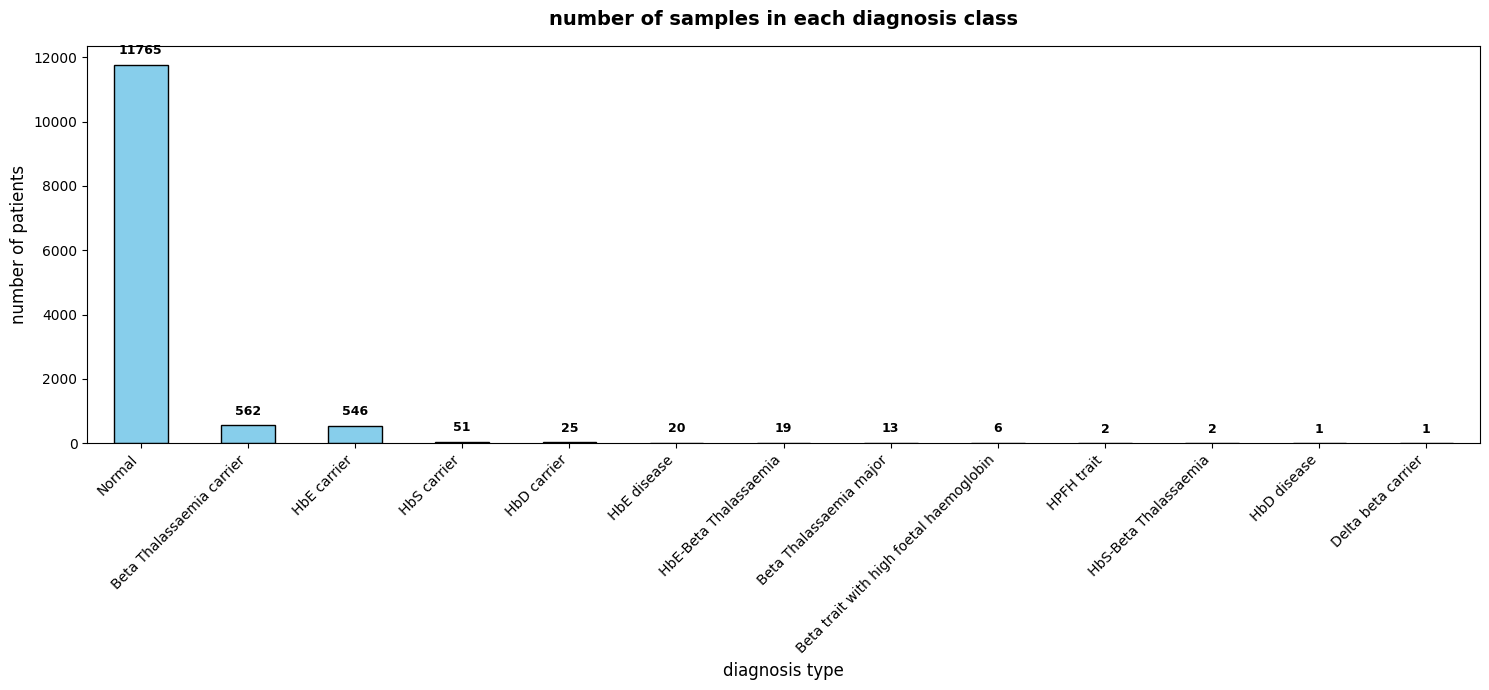

In [14]:
counts=data["Diagnosis"].value_counts()
counts.index=lb.classes_[counts.index]

plt.figure(figsize=(15,7))

counts.plot(kind='bar',color='skyblue', edgecolor='black')

plt.title('number of samples in each diagnosis class', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('diagnosis type', fontsize=12)
plt.ylabel('number of patients', fontsize=12)

plt.xticks(rotation=45,ha='right',fontsize=10)

max_val=counts.max()
for index,value in enumerate(counts):
    plt.text(index, value+(max_val * 0.02),str(value),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
data.isnull().sum()

Age          0
Gender       0
HbA0         0
HbA2         0
HbF          0
S-Window     0
RBC          0
HB           0
MCV          0
MCH          0
MCHC         0
RDWcv        0
Weekness     0
Jaundice     0
Diagnosis    0
dtype: int64

In [16]:
data["target"]=np.where(data['Diagnosis']==12,0,1)

In [17]:
print(data["target"].value_counts())

target
0    11765
1     1248
Name: count, dtype: int64


In [18]:
print(data.columns)

Index(['Age', 'Gender', 'HbA0', 'HbA2', 'HbF', 'S-Window', 'RBC', 'HB', 'MCV',
       'MCH', 'MCHC', 'RDWcv', 'Weekness', 'Jaundice', 'Diagnosis', 'target'],
      dtype='object')


In [19]:
data=data.drop(columns=["Diagnosis"])
data

,Age,Gender,HbA0,HbA2,HbF,S-Window,RBC,HB,MCV,MCH,MCHC,RDWcv,Weekness,Jaundice,target
0,63,0,86.2,2.9,0.3,0.0,4.81,13.2,86.7,28.8,33.0,13.8,0,0,0
1,84,0,86.4,4.8,0.4,0.0,4.18,10.9,78.9,26.1,33.0,14.6,0,0,1
2,88,1,87.3,3.2,0.5,0.0,5.31,13.6,87.0,25.6,29.4,13.7,0,0,0
3,154,0,87.9,2.8,0.2,0.0,4.64,11.5,78.7,44.8,31.5,14.5,0,0,0
4,334,1,84.3,2.8,0.2,0.0,5.50,14.0,69.7,21.5,30.9,16.5,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,2,1,79.3,2.9,5.8,0.0,2.07,6.1,89.4,29.5,33.0,19.5,0,0,1
13027,3,0,77.2,2.7,8.1,0.0,2.47,6.3,81.0,25.5,31.5,16.4,0,0,1
13028,4,1,21.3,62.9,5.2,0.0,5.26,10.0,60.3,19.0,31.5,24.1,0,0,1
13029,4,1,87.5,3.3,0.2,0.0,4.60,13.4,84.1,29.1,34.6,14.4,0,0,0


In [20]:
x=data.drop(columns=['target'])
y=data["target"]

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y,shuffle=True)

print("train shape:",x_train.shape,y_train.shape)
print("test shape:",x_test.shape,y_test.shape)


train shape: (10410, 14) (10410,)
test shape: (2603, 14) (2603,)


In [22]:
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2,random_state=42)
print("val shape:",x_val.shape,y_val.shape)

val shape: (2082, 14) (2082,)


In [23]:
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)
x_val_sc=sc.transform(x_val)

print("x train:",x_train_sc[:5])
print("x test:",x_test_sc[:5])
print("x val:",x_val_sc[:5])

x train: [[ 0.24353083 -0.665265    0.32857873 -0.24329321 -0.1962204  -0.0600533
  -0.11486585 -0.79546809 -0.68987894 -0.81899773 -0.30537792  0.47497279
  -0.03954035 -0.04781921]
 [-0.52910165  1.5031604   0.10246237 -0.12897762 -0.1962204  -0.0600533
  -1.54392387 -0.05958112  2.55275851  2.19396458  0.27457913  2.61995652
  -0.03954035 -0.04781921]
 [ 1.36251579 -0.665265    0.342711   -0.17797002 -0.1414502  -0.0600533
  -0.95209176 -0.90868146 -0.12692105  0.07179113  0.22414808  3.42432542
  -0.03954035 -0.04781921]
 [ 2.11738659 -0.665265    0.03180101 -0.29228561 -0.03190982 -0.0600533
   1.44410654  0.16684563 -0.54350989 -1.29059183 -0.98619707  0.56434712
  -0.03954035 -0.04781921]
 [-1.10635579  1.5031604   0.13072691 -0.19430081 -0.1414502  -0.0600533
   0.49140119  0.44987908  0.19959453 -0.16400592 -0.30537792  0.11747551
  -0.03954035 -0.04781921]]
x test: [[ 1.10497163 -0.665265    0.15899146 -0.25962401 -0.1962204  -0.0600533
  -0.96652669 -0.05958112  0.41351853  

In [24]:
print(x_train_sc.shape[1])

14


In [25]:
model=Sequential()
model.add(Dense(12,activation='relu',input_shape=(14,)))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
compile=model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [27]:
from sklearn.utils.class_weight import compute_class_weight
we=compute_class_weight('balanced',classes=np.unique(y_train),y=y_train)
class_w={0:we[0],1:we[1]}
print(f"class_weight={class_w}")

class_weight={0: 0.5522546419098143, 1: 5.284263959390863}


In [ ]:
history=model.fit(x_train_sc,y_train,epochs=50,batch_size=10,validation_data=(x_val_sc,y_val),class_weight=class_w)

Epoch 1/50
793/833 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.6335 - loss: 0.4546

In [25]:
model.save("HPLC.keras")

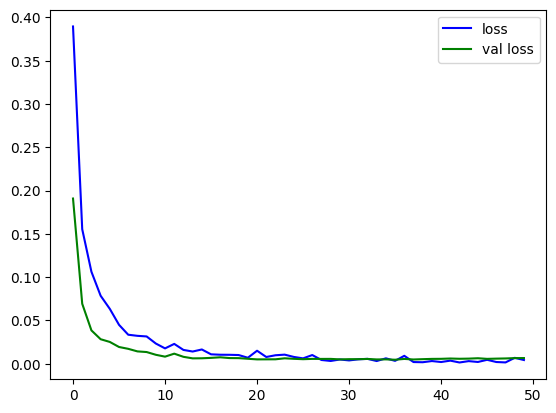

In [26]:
plt.plot(history.history['loss'],color='blue',label="loss")
plt.plot(history.history["val_loss"],color='green',label="val loss")
plt.legend()
plt.show()

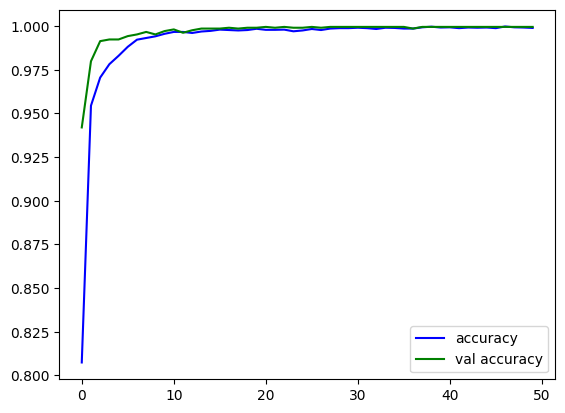

In [27]:
plt.plot(history.history['accuracy'],color='blue',label="accuracy")
plt.plot(history.history["val_accuracy"],color='green',label="val accuracy")
plt.legend()
plt.show()

In [28]:
model=load_model("HPLC.keras")

In [29]:
y_pred_probs=model.predict(x_test_sc)
y_pr=(y_pred_probs>0.5).astype(int).flatten()

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step


In [30]:
from sklearn.metrics import accuracy_score,recall_score,precision_score

print("accuracy: ",accuracy_score(y_pr,y_test))
print("recall: ",recall_score(y_pr,y_test))
print("precision: ",precision_score(y_pr,y_test))

accuracy:  0.998849252013809
recall:  0.9959839357429718
precision:  0.992


In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_pr,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2358
           1       0.99      1.00      0.99       249

    accuracy                           1.00      2607
   macro avg       1.00      1.00      1.00      2607
weighted avg       1.00      1.00      1.00      2607



In [32]:
print(data["Gender"])

0        0
1        0
2        1
3        0
4        1
        ..
13026    1
13027    0
13028    1
13029    1
13030    1
Name: Gender, Length: 13031, dtype: int32


In [33]:
for i,txt in enumerate(lb2.classes_):
    print(f"{i}: {txt}")

0: 0 Yrs 11 month
1: 0 Yrs 9 month
2: 1 Yrs 0 month
3: 1 Yrs 1 month
4: 1 Yrs 11 month
5: 1 Yrs 2 month
6: 1 Yrs 4 month
7: 1 Yrs 5 month
8: 1 Yrs 6 month
9: 1 Yrs 7 month
10: 1 Yrs 8 month
11: 1 Yrs 9 month
12: 10 Yrs 0 month
13: 10 Yrs 1 month
14: 10 Yrs 10 month
15: 10 Yrs 11 month
16: 10 Yrs 2 month
17: 10 Yrs 3 month
18: 10 Yrs 4 month
19: 10 Yrs 5 month
20: 10 Yrs 6 month
21: 10 Yrs 7 month
22: 10 Yrs 8 month
23: 10 Yrs 9 month
24: 11 Yrs 0 month
25: 11 Yrs 1 month
26: 11 Yrs 10 month
27: 11 Yrs 11 month
28: 11 Yrs 2 month
29: 11 Yrs 3 month
30: 11 Yrs 4 month
31: 11 Yrs 5 month
32: 11 Yrs 6 month
33: 11 Yrs 7 month
34: 11 Yrs 8 month
35: 11 Yrs 9 month
36: 12 Yrs 0 month
37: 12 Yrs 1 month
38: 12 Yrs 10 month
39: 12 Yrs 11 month
40: 12 Yrs 2 month
41: 12 Yrs 3 month
42: 12 Yrs 4 month
43: 12 Yrs 5 month
44: 12 Yrs 6 month
45: 12 Yrs 7 month
46: 12 Yrs 8 month
47: 12 Yrs 9 month
48: 13 Yrs 0 month
49: 13 Yrs 1 month
50: 13 Yrs 10 month
51: 13 Yrs 11 month
52: 13 Yrs 2 month
53: 1

In [34]:
for i,txt in enumerate(lb5.classes_):
    print(f"{i}: {txt}")

0: Female
1: Male


In [35]:
for i,txt in enumerate(lb3.classes_):
    print(f"{i}: {txt}")

0: No
1: Yes
2: nan


In [188]:
sick_stats=x[y==1].mean()

print(f"MCV: {sick_stats['MCV']:.1f}")
print(f"MCH: {sick_stats['MCH']:.1f}")
print(f"HbA2: {sick_stats['HbA2']:.1f}")
print(f"HB: {sick_stats['HB']:.1f}")
print(f"RBC: {sick_stats['RBC']:.1f}")

MCV: 73.0
MCH: 23.0
HbA2: 16.6
HB: 10.9
RBC: 4.8


In [189]:
healthy_stats=x[y==0].mean()

print(f"MCV: {healthy_stats['MCV']:.1f}")
print(f"MCH: {healthy_stats['MCH']:.1f}")
print(f"HbA2: {healthy_stats['HbA2']:.1f}")
print(f"HB: {healthy_stats['HB']:.1f}")
print(f"RBC: {healthy_stats['RBC']:.1f}")

MCV: 86.7
MCH: 28.1
HbA2: 3.0
HB: 11.9
RBC: 4.3


In [150]:
patient_thalassemia=pd.DataFrame({
    'Age':[515],
    'Gender':[0],
    'HbA0':[70.8],
    'HbA2':[16.5],
    'HbF':[1.6],
    'S-Window':[1],
    'RBC':[4.8],
    'HB':[10.9],
    'MCV':[73.0],
    'MCH':[23.0],
    'MCHC':[31.7],
    'RDWcv':[16.0],
    'Weekness':[1],
    'Jaundice':[0]
})

In [151]:
patient_healthy=pd.DataFrame({
    'Age': [535],
    'Gender':[0],
    'HbA0':[96.5],
    'HbA2':[2.8],
    'HbF':[0.7],
    'S-Window': [0],
    'RBC':[4.8],
    'HB':[13.5],
    'MCV':[88.0],
    'MCH':[28.5],
    'MCHC':[32.0],
    'RDWcv':[13.5],
    'Weekness':[0],
    'Jaundice':[0]
})

In [152]:
th_sc=sc.transform(patient_thalassemia)
h_sc=sc.transform(patient_healthy)

In [153]:
p_sick=model.predict(th_sc)[0][0]
p_healthy= model.predict(h_sc)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [154]:
print(f"sick: {p_sick*100:.2f}%")
print(f"healthy: {(1-p_healthy)*100:.2f}%")

sick: 100.00%
healthy: 100.00%


In [164]:
patient_thalassemia2=pd.DataFrame({
    'Age': [84],
    'Gender':[0],
    'HbA0':[70.8],
    'HbA2':[16.5],
    'HbF':[1.6],
    'S-Window':[1],
    'RBC':[4.8],
    'HB':[10.9],
    'MCV':[73.0],
    'MCH':[23.0],
    'MCHC':[31.7],
    'RDWcv':[16.0],
    'Weekness':[1],
    'Jaundice':[0]
})

In [165]:
patient_healthy2=pd.DataFrame({
    'Age':[544],
    'Gender':[0],
    'HbA0':[96.0],
    'HbA2':[3.0],
    'HbF':[0.7],
    'S-Window':[0],
    'RBC':[4.3],
    'HB':[11.9],
    'MCV':[86.7],
    'MCH':[28.1],
    'MCHC':[32.0],
    'RDWcv':[13.5],
    'Weekness':[0],
    'Jaundice':[0]
})

In [166]:
th_sc2=sc.transform(patient_thalassemia2)
h_sc2=sc.transform(patient_healthy2)

In [167]:
p_sick2=model.predict(th_sc2)[0][0]
p_h2=model.predict(h_sc2)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [170]:
print(f"sick: {p_sick2*100:.2f}%")
print(f"healthy: {(1-p_h2)*100:.2f}%")

sick: 100.00%
healthy: 100.00%


In [171]:
from sklearn.metrics import precision_recall_curve

pred_l=y_pred_probs.flatten()

precision,recall,thresholds=precision_recall_curve(y_test, pred_l)

f1=2*(precision*recall)/(precision+recall+1e-10)
bst_th=thresholds[np.argmax(f1[:-1])]

print(f" best threshold: {bst_th:.3f}")

 best threshold: 0.650


In [177]:
patient_sick = pd.DataFrame({'Age':[202], 'Gender':[0], 'HbA0': [70.8], 'HbA2': [16.5], 'HbF': [1.6],
    'S-Window':[1], 'RBC':[4.8], 'HB':[10.9], 'MCV': [73.0], 'MCH': [23.0],
    'MCHC':[31.7], 'RDWcv':[16.0], 'Weekness':[1], 'Jaundice':[0]})

patient_healthy = pd.DataFrame({'Age': [202], 'Gender': [0], 'HbA0': [96.0], 'HbA2': [3.0], 'HbF': [0.7],'S-Window': [0], 'RBC': [4.3], 'HB': [11.9], 'MCV': [86.7], 'MCH': [28.1],'MCHC': [32.0], 'RDWcv': [13.5], 'Weekness': [0], 'Jaundice': [0]
})

In [178]:
sc_sick3=sc.transform(patient_sick)
sc_healthy3=sc.transform(patient_healthy)

In [179]:
pr_sick=model.predict(sc_sick3)[0][0]
pr_healthy=model.predict(sc_healthy3)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [180]:
def show_r(name,pr):
    percent_sick=pr*100
    percent_healthy=(1-pr)*100

    dia="sick" if pr>0.7 else "healthy"

    print(f"ms/mr {name}")
    print(f" result: {dia}")
    print(f"model think sick:  {percent_sick:.2f}%")
    print(f"model think healthy: {percent_healthy:.2f}%")

In [181]:
show_r("patient 1:",pr_sick)
show_r("patient 2:",pr_healthy)

ms/mr patient 1:
 result: sick
model think sick:  100.00%
model think healthy: 0.00%
ms/mr patient 2:
 result: healthy
model think sick:  0.00%
model think healthy: 100.00%


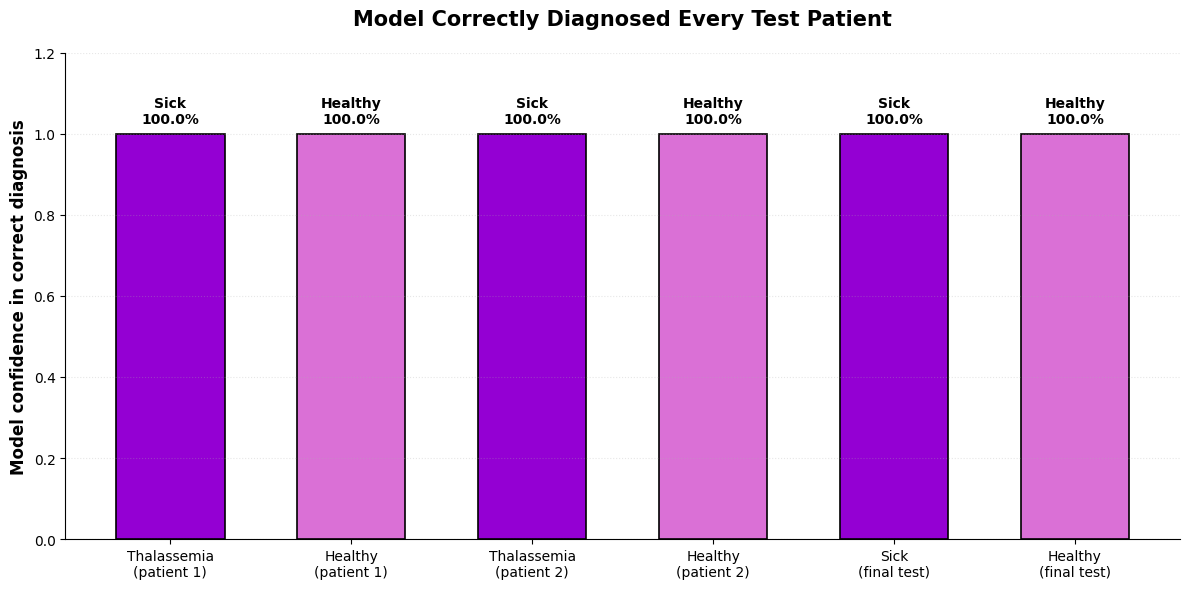

In [190]:
import matplotlib.pyplot as plt

names=['Thalassemia\n(patient 1)', 'Healthy\n(patient 1)','Thalassemia\n(patient 2)', 'Healthy\n(patient 2)','Sick\n(final test)', 'Healthy\n(final test)']

raw_probs=[p_sick, p_healthy, p_sick2, p_h2, pr_sick, pr_healthy]
expected=[1,0,1,0,1,0]

display_probs=[p if exp==1 else (1-p) for p, exp in zip(raw_probs, expected)]

colors=['darkviolet' if exp==1 else 'orchid' for exp in expected]
fig,ax=plt.subplots(figsize=(12, 6))
bars=ax.bar(names,display_probs,color=colors, edgecolor='black', linewidth=1.2, width=0.6)

for bar, prob, exp in zip(bars, display_probs, expected):
    height = bar.get_height()
    result_label = 'Sick' if exp==1 else 'Healthy'
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,f'{result_label}\n{prob*100:.1f}%', ha='center', va='bottom',fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.2)
ax.set_ylabel('Model confidence in correct diagnosis', fontsize=12, fontweight='bold')
ax.set_title('Model Correctly Diagnosed Every Test Patient', fontsize=15, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('model_test_results.png', dpi=150, bbox_inches='tight')
plt.show()